# Phần 02 - Trực quan hóa và Phân tích Dữ liệu

Notebook nay tap trung tra loi 4 cau hoi kinh doanh chinh:
1. Vi sao traffic van tang nhung doanh thu va so don hang giam sau 2016?
2. Khuyen mai dang giup tang truong hay dang an mon bien loi nhuan?
3. Nguyen nhan tra hang nao dang gay ton that lon nhat?
4. Doanh thu dang tap trung vao nhom khach hang nao, va nen uu tien giu chan ai?

## Import

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")
pd.options.display.float_format = "{:,.2f}".format

BLUE = "#4C72B0"
RED = "#C44E52"
GREEN = "#55A868"
GOLD = "#CCB974"
PURPLE = "#8172B2"


def fmt_billions(value, _):
    return f"{value / 1e9:.1f}B"


def fmt_millions(value, _):
    return f"{value / 1e6:.1f}M"

## Load dataset

In [2]:
orders = pd.read_csv("dataset/orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv("dataset/order_items.csv", dtype={"promo_id_2": str})
products = pd.read_csv("dataset/products.csv")
promotions = pd.read_csv("dataset/promotions.csv", parse_dates=["start_date", "end_date"])
returns = pd.read_csv("dataset/returns.csv", parse_dates=["return_date"])
reviews = pd.read_csv("dataset/reviews.csv", parse_dates=["review_date"])
customers = pd.read_csv("dataset/customers.csv", parse_dates=["signup_date"], low_memory=False)
sales = pd.read_csv("dataset/sales.csv", parse_dates=["Date"])
web = pd.read_csv("dataset/web_traffic.csv", parse_dates=["date"])

print("Dataset shapes:")
print(f"- orders: {orders.shape}")
print(f"- order_items: {order_items.shape}")
print(f"- products: {products.shape}")
print(f"- promotions: {promotions.shape}")
print(f"- returns: {returns.shape}")
print(f"- reviews: {reviews.shape}")
print(f"- sales: {sales.shape}")
print(f"- web_traffic: {web.shape}")

Dataset shapes:
- orders: (646945, 8)
- order_items: (714669, 7)
- products: (2412, 8)
- promotions: (50, 10)
- returns: (39939, 7)
- reviews: (113551, 7)
- sales: (3833, 3)
- web_traffic: (3652, 7)


In [ ]:
# ==============================
# 1. Chuan bi cac bang phan tich
# ==============================
items = order_items.merge(
    products[["product_id", "category", "segment", "size", "cogs"]],
    on="product_id",
    how="left"
)
items["gross_sales"] = items["quantity"] * items["unit_price"]
items["net_sales"] = items["gross_sales"] - items["discount_amount"]
items["gross_profit"] = items["quantity"] * (items["unit_price"] - items["cogs"]) - items["discount_amount"]
items["promo_used"] = items["promo_id"].notna() | items["promo_id_2"].notna()

# Monthly business KPIs
sales["month"] = sales["Date"].dt.to_period("M").dt.to_timestamp()
web["month"] = web["date"].dt.to_period("M").dt.to_timestamp()
orders["month"] = orders["order_date"].dt.to_period("M").dt.to_timestamp()

monthly_sales = sales.groupby("month").agg(
    revenue=("Revenue", "sum"),
    cogs=("COGS", "sum")
)
monthly_sales["gross_margin"] = (monthly_sales["revenue"] - monthly_sales["cogs"]) / monthly_sales["revenue"]

monthly_web = web.groupby("month").agg(
    sessions=("sessions", "sum"),
    visitors=("unique_visitors", "sum"),
    bounce_rate=("bounce_rate", "mean"),
    avg_session_duration_sec=("avg_session_duration_sec", "mean")
)

monthly_orders = orders.groupby("month").agg(orders=("order_id", "count"))
monthly_orders["returned_orders"] = (
    orders.assign(is_return=orders["order_status"].eq("returned").astype(int))
    .groupby("month")["is_return"]
    .sum()
)
monthly_orders["return_rate"] = monthly_orders["returned_orders"] / monthly_orders["orders"]

monthly_kpis = (
    monthly_sales
    .join(monthly_web, how="inner")
    .join(monthly_orders, how="inner")
    .reset_index()
)
monthly_kpis = monthly_kpis[monthly_kpis["visitors"] > 0].copy()
monthly_kpis["orders_per_1000_visitors"] = monthly_kpis["orders"] / monthly_kpis["visitors"] * 1000
monthly_kpis["revenue_per_session"] = monthly_kpis["revenue"] / monthly_kpis["sessions"]
monthly_kpis["revenue_rolling_6m"] = monthly_kpis["revenue"].rolling(6, min_periods=3).mean()

trend_x = np.arange(len(monthly_kpis))
trend_coef = np.polyfit(trend_x, monthly_kpis["orders_per_1000_visitors"], 1)
monthly_kpis["conversion_trend"] = np.polyval(trend_coef, trend_x)

yearly_kpis = monthly_kpis.assign(year=monthly_kpis["month"].dt.year).groupby("year").agg(
    revenue=("revenue", "sum"),
    sessions=("sessions", "sum"),
    visitors=("visitors", "sum"),
    orders=("orders", "sum")
)
yearly_kpis["orders_per_1000_visitors"] = yearly_kpis["orders"] / yearly_kpis["visitors"] * 1000
yearly_kpis["aov"] = yearly_kpis["revenue"] / yearly_kpis["orders"]

# Promotion economics
promo_perf = items.groupby(["category", "promo_used"]).agg(
    net_sales=("net_sales", "sum"),
    gross_profit=("gross_profit", "sum"),
    quantity=("quantity", "sum")
).reset_index()
promo_perf["gross_margin_pct"] = promo_perf["gross_profit"] / promo_perf["net_sales"] * 100
promo_perf["promo_label"] = np.where(promo_perf["promo_used"], "With promo", "Without promo")

# Returns analysis
return_reasons = returns.groupby("return_reason").agg(
    returns=("return_id", "count"),
    refund=("refund_amount", "sum")
).sort_values("refund", ascending=False).reset_index()
return_reasons["cum_refund_pct"] = return_reasons["refund"].cumsum() / return_reasons["refund"].sum() * 100
return_reasons["refund_share_pct"] = return_reasons["refund"] / return_reasons["refund"].sum() * 100

return_items = returns.merge(products[["product_id", "category", "size"]], on="product_id", how="left")
return_matrix = (
    items.groupby(["category", "size"])["quantity"].sum().rename("sold_qty").to_frame()
    .join(return_items.groupby(["category", "size"])["return_quantity"].sum().rename("return_qty"))
    .fillna(0)
)
return_matrix["return_rate_pct"] = return_matrix["return_qty"] / return_matrix["sold_qty"] * 100
return_heatmap = return_matrix["return_rate_pct"].unstack().reindex(columns=["S", "M", "L", "XL"])

# Customer value concentration (RFM)
order_value = items.groupby("order_id")["net_sales"].sum().rename("net_sales").reset_index()
orders_value = orders.merge(order_value, on="order_id", how="left")
reference_date = orders_value["order_date"].max() + pd.Timedelta(days=1)

rfm = orders_value.groupby("customer_id").agg(
    Recency=("order_date", lambda x: (reference_date - x.max()).days),
    Frequency=("order_id", "nunique"),
    Monetary=("net_sales", "sum")
).reset_index()
rfm["R"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M"] = pd.qcut(rfm["Monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

conditions = [
    (rfm["R"] >= 4) & (rfm["F"] >= 4) & (rfm["M"] >= 4),
    (rfm["R"] >= 3) & (rfm["F"] >= 3),
    (rfm["R"] <= 2) & (rfm["F"] >= 4),
    (rfm["R"] <= 2) & (rfm["F"] <= 2) & (rfm["M"] <= 2),
    (rfm["R"] >= 4) & (rfm["F"] <= 2)
]
labels = ["Champions", "Loyal", "At Risk", "Hibernating", "New"]
rfm["segment"] = np.select(conditions, labels, default="Potential")

segment_summary = rfm.groupby("segment").agg(
    customers=("customer_id", "nunique"),
    revenue=("Monetary", "sum"),
    avg_recency=("Recency", "mean"),
    avg_frequency=("Frequency", "mean")
).sort_values("revenue", ascending=False)
segment_summary["customer_share_pct"] = segment_summary["customers"] / segment_summary["customers"].sum() * 100
segment_summary["revenue_share_pct"] = segment_summary["revenue"] / segment_summary["revenue"].sum() * 100

rfm_sample = rfm.sample(min(5000, len(rfm)), random_state=42)

# Buying cadence
inter_order_gap = orders.sort_values(["customer_id", "order_date"]).copy()
inter_order_gap["gap_days"] = inter_order_gap.groupby("customer_id")["order_date"].diff().dt.days
gap_series = inter_order_gap["gap_days"].dropna()

# Summary metrics for narrative cells
summary_metrics = {
    "revenue_peak_year": int(yearly_kpis["revenue"].idxmax()),
    "revenue_peak_value": yearly_kpis["revenue"].max(),
    "revenue_2022": yearly_kpis.loc[2022, "revenue"],
    "sessions_growth_16_22": (yearly_kpis.loc[2022, "sessions"] / yearly_kpis.loc[2016, "sessions"] - 1) * 100,
    "orders_change_16_22": (yearly_kpis.loc[2022, "orders"] / yearly_kpis.loc[2016, "orders"] - 1) * 100,
    "conversion_change_16_22": (yearly_kpis.loc[2022, "orders_per_1000_visitors"] / yearly_kpis.loc[2016, "orders_per_1000_visitors"] - 1) * 100,
    "promo_sales_share": items.loc[items["promo_used"], "net_sales"].sum() / items["net_sales"].sum() * 100,
    "promo_margin": items.loc[items["promo_used"], "gross_profit"].sum() / items.loc[items["promo_used"], "net_sales"].sum() * 100,
    "nonpromo_margin": items.loc[~items["promo_used"], "gross_profit"].sum() / items.loc[~items["promo_used"], "net_sales"].sum() * 100,
    "wrong_size_refund_share": return_reasons.loc[return_reasons["return_reason"].eq("wrong_size"), "refund_share_pct"].iloc[0],
    "top_return_rate": return_matrix["return_rate_pct"].max(),
    "top_return_rate_group": return_matrix["return_rate_pct"].idxmax(),
    "champions_customer_share": segment_summary.loc["Champions", "customer_share_pct"],
    "champions_revenue_share": segment_summary.loc["Champions", "revenue_share_pct"],
    "hibernating_customer_share": segment_summary.loc["Hibernating", "customer_share_pct"],
    "hibernating_revenue_share": segment_summary.loc["Hibernating", "revenue_share_pct"],
    "median_gap_days": gap_series.median(),
    "gap_q75": gap_series.quantile(0.75)
}

Da san sang cac bang tong hop cho phan visual va phan tich.


## Storyline tong quat

- **Traffic khong con la nut that.** Tu {summary_metrics['revenue_peak_year']} den 2022, sessions van tang **{summary_metrics['sessions_growth_16_22']:.1f}%** nhung so don hang giam **{abs(summary_metrics['orders_change_16_22']):.1f}%**.
- **Khuyen mai dang mua doanh thu bang bien loi nhuan.** Khoang **{summary_metrics['promo_sales_share']:.1f}%** net sales den tu cac dong co promo, nhung bien loi nhuan gop cua nhom nay la **{summary_metrics['promo_margin']:.1f}%**.
- **Tra hang tap trung vao mot vai nguyen nhan co the hanh dong duoc.** Rieng `wrong_size` da chiem **{summary_metrics['wrong_size_refund_share']:.1f}%** tong refund.
- **Doanh thu phu thuoc rat manh vao nhom gia tri cao.** Segment `Champions` chi chiem **{summary_metrics['champions_customer_share']:.1f}%** khach hang nhung tao ra **{summary_metrics['champions_revenue_share']:.1f}%** doanh thu.

Phan con lai cua notebook se di tu phieu qua phieu hon: tu phan tich tang truong, sang kinh te khuyen mai, sau do mo xe tra hang va cuoi cung la uu tien giu chan khach hang.

## 1. Tang truong va hieu qua phieu chuyen doi

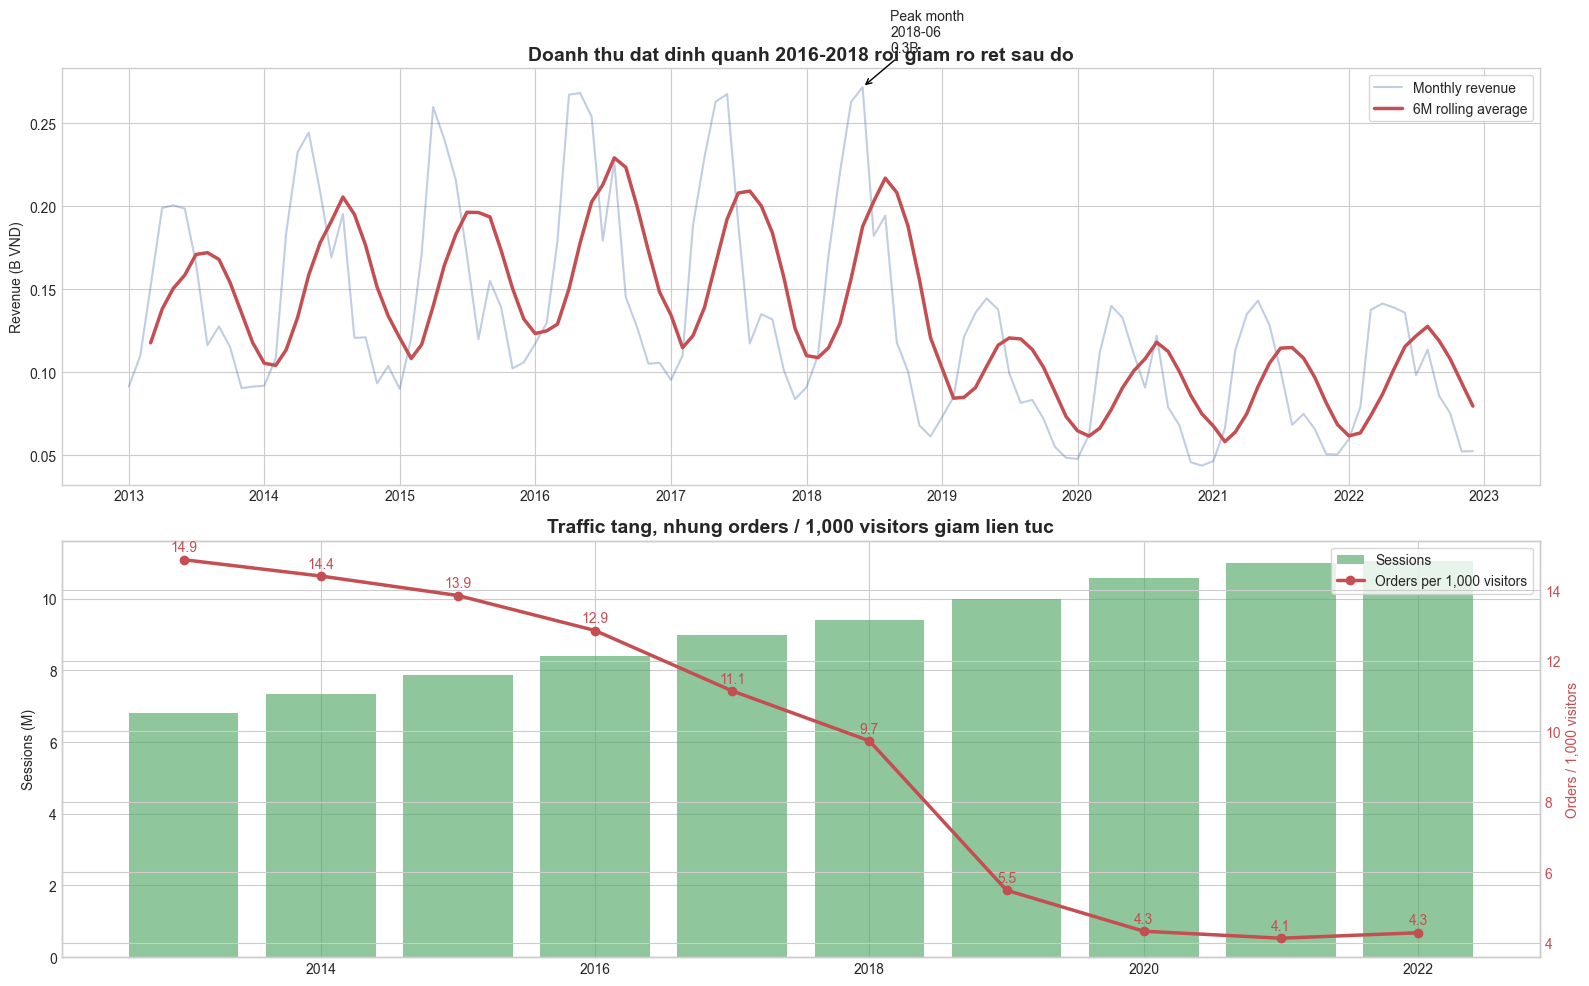

In [5]:
display(Markdown("## 1. Tang truong va hieu qua phieu chuyen doi"))

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)

# Subplot 1: doanh thu theo thang va xu huong 6M rolling
axes[0].plot(monthly_kpis["month"], monthly_kpis["revenue"] / 1e9, color=BLUE, alpha=0.35, linewidth=1.5, label="Monthly revenue")
axes[0].plot(monthly_kpis["month"], monthly_kpis["revenue_rolling_6m"] / 1e9, color=RED, linewidth=2.5, label="6M rolling average")
axes[0].set_title("Doanh thu dat dinh quanh 2016-2018 roi giam ro ret sau do", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Revenue (B VND)")
axes[0].legend(frameon=True)

peak_month = monthly_kpis.loc[monthly_kpis["revenue"].idxmax()]
axes[0].annotate(
    f"Peak month\n{peak_month['month']:%Y-%m}\n{peak_month['revenue']/1e9:.1f}B",
    xy=(peak_month["month"], peak_month["revenue"] / 1e9),
    xytext=(20, 25),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="black")
)

# Subplot 2: traffic tang nhung chuyen doi giam
ax2 = axes[1]
ax2.bar(yearly_kpis.index, yearly_kpis["sessions"] / 1e6, color=GREEN, alpha=0.65, label="Sessions")
ax2.set_ylabel("Sessions (M)")
ax2.set_title("Traffic tang, nhung orders / 1,000 visitors giam lien tuc", fontsize=14, fontweight="bold")

ax2b = ax2.twinx()
ax2b.plot(yearly_kpis.index, yearly_kpis["orders_per_1000_visitors"], color=RED, marker="o", linewidth=2.5, label="Orders per 1,000 visitors")
ax2b.set_ylabel("Orders / 1,000 visitors", color=RED)
ax2b.tick_params(axis="y", labelcolor=RED)

handles1, labels1 = ax2.get_legend_handles_labels()
handles2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(handles1 + handles2, labels1 + labels2, loc="upper right", frameon=True)

for year, value in yearly_kpis["orders_per_1000_visitors"].items():
    ax2b.annotate(f"{value:.1f}", (year, value), textcoords="offset points", xytext=(0, 6), ha="center", color=RED)

plt.tight_layout()
plt.show()

### Phan tich 1 - Growth paradox

**Descriptive.** Doanh thu dat dinh vao giai doan {summary_metrics['revenue_peak_year']} - 2018, nhung den 2022 chi con **{summary_metrics['revenue_2022'] / 1e9:.1f}B VND**. Cung luc do, sessions van tang **{summary_metrics['sessions_growth_16_22']:.1f}%** so voi 2016.

**Diagnostic.** Van de nam o chat luong traffic va hieu qua chuyen doi, khong nam o quy mo traffic. So don hang giam **{abs(summary_metrics['orders_change_16_22']):.1f}%**, trong khi chi so `orders / 1,000 visitors` giam **{abs(summary_metrics['conversion_change_16_22']):.1f}%**. Nghia la doanh nghiep dang mua duoc nhieu luot ghe tham hon, nhung khong bien thanh mua hang.

**Predictive.** Duong xu huong thang cho thay hieu qua chuyen doi van dang di xuong. Neu khong cai thien chat luong acquisition, traffic tang them se tiep tuc dem lai doanh thu bien do nho dan.

**Prescriptive.** Uu tien 3 hanh dong: (1) toi uu kenh acquisition theo `orders per visitor` thay vi chi theo sessions, (2) audit landing page / checkout cho giai doan sau 2018, (3) tach dashboard theo kenh traffic de cat cac kenh dem nhieu visit nhung khong ra don.

## 2. Hieu qua khuyen mai va bien loi nhuan

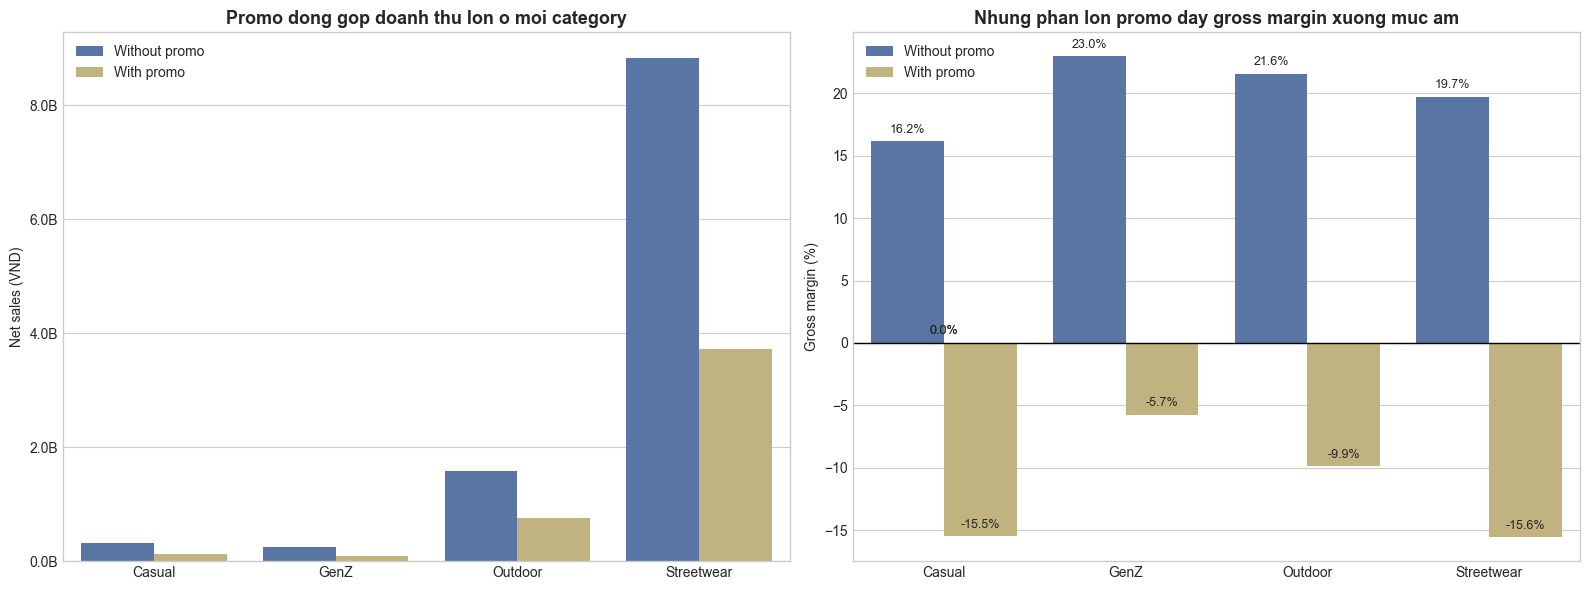

In [7]:
display(Markdown("## 2. Hieu qua khuyen mai va bien loi nhuan"))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_data = promo_perf.copy()

sns.barplot(
    data=plot_data,
    x="category",
    y="net_sales",
    hue="promo_label",
    ax=axes[0],
    palette=[BLUE, GOLD]
)
axes[0].set_title("Promo dong gop doanh thu lon o moi category", fontsize=13, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Net sales (VND)")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(fmt_billions))
axes[0].legend(title="")

sns.barplot(
    data=plot_data,
    x="category",
    y="gross_margin_pct",
    hue="promo_label",
    ax=axes[1],
    palette=[BLUE, GOLD]
)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Nhung phan lon promo day gross margin xuong muc am", fontsize=13, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Gross margin (%)")
axes[1].legend(title="")

for patch in axes[1].patches:
    height = patch.get_height()
    x = patch.get_x() + patch.get_width() / 2
    axes[1].annotate(f"{height:.1f}%", (x, height), ha="center", va="bottom", fontsize=9, xytext=(0, 4), textcoords="offset points")

plt.tight_layout()
plt.show()

### Phan tich 2 - Promotion economics

**Descriptive.** Cac dong co promo dong gop **{summary_metrics['promo_sales_share']:.1f}%** net sales toan bo du lieu. O ca 4 category, promo deu day doanh thu len dang ke.

**Diagnostic.** Van de la bi doanh thu tang nhung lai loi nhuan bi am. Gross margin cua nhom khong promo dat **{summary_metrics['nonpromo_margin']:.1f}%**, trong khi nhom co promo roi xuong **{summary_metrics['promo_margin']:.1f}%**. Streetwear va Casual la 2 nhom bi an mon manh nhat, ham y discount dang vuot qua room margin san co.

**Predictive.** Neu tiep tuc scale cac campaign theo logic volume-only, doanh nghiep co the giu GMV nhung se de bi suy giam gross profit trong cac mua cao diem tiep theo.

**Prescriptive.** Nen chuyen tu KPI `sales uplift` sang `incremental gross profit`, dat tran discount theo category margin, va uu tien campaign stackable / discount nhe cho nhom co bien loi nhuan mong.

## 3. Mo xe chi phi tra hang

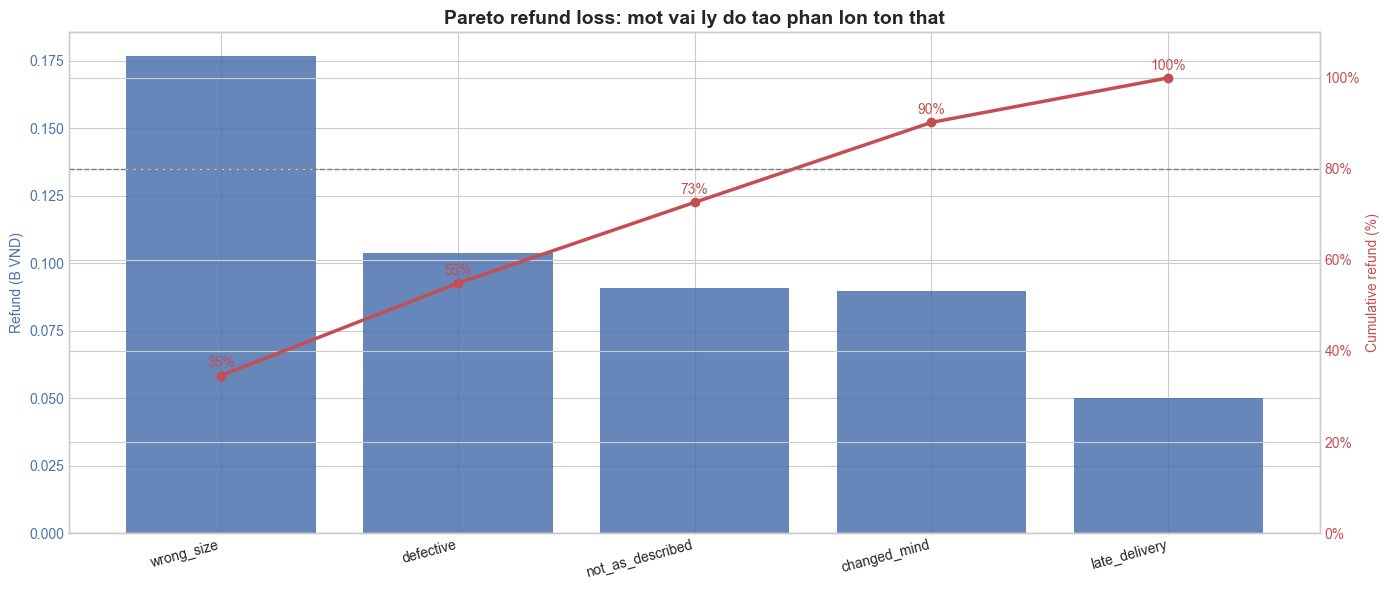

In [9]:
display(Markdown("## 3. Mo xe chi phi tra hang"))

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(return_reasons["return_reason"], return_reasons["refund"] / 1e9, color=BLUE, alpha=0.85)
ax1.set_ylabel("Refund (B VND)", color=BLUE)
ax1.tick_params(axis="y", labelcolor=BLUE)
ax1.set_xlabel("")
ax1.set_title("Pareto refund loss: mot vai ly do tao phan lon ton that", fontsize=14, fontweight="bold")
ax1.set_xticklabels(return_reasons["return_reason"], rotation=15, ha="right")

ax2 = ax1.twinx()
ax2.plot(return_reasons["return_reason"], return_reasons["cum_refund_pct"], color=RED, marker="o", linewidth=2.5)
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("Cumulative refund (%)", color=RED)
ax2.tick_params(axis="y", labelcolor=RED)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.set_ylim(0, 110)

for i, value in enumerate(return_reasons["cum_refund_pct"]):
    ax2.annotate(f"{value:.0f}%", (i, value), textcoords="offset points", xytext=(0, 6), ha="center", color=RED)

plt.tight_layout()
plt.show()

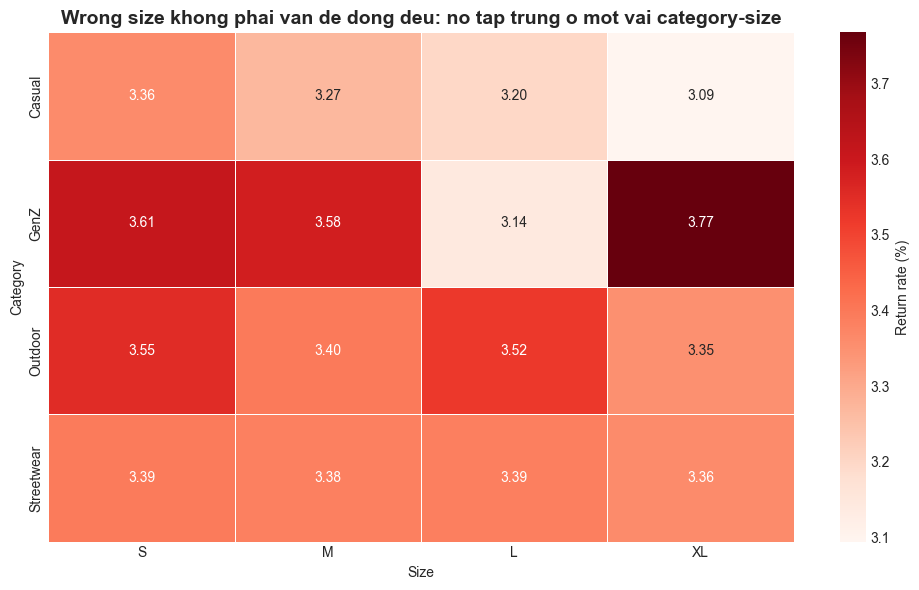

In [10]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    return_heatmap,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    linewidths=0.5,
    cbar_kws={"label": "Return rate (%)"}
)
plt.title("Wrong size khong phai van de dong deu: no tap trung o mot vai category-size", fontsize=14, fontweight="bold")
plt.xlabel("Size")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

### Phan tich 3 - Returns are operationally actionable

**Descriptive.** `wrong_size` la ly do gay ton that lon nhat, chiem **{summary_metrics['wrong_size_refund_share']:.1f}%** tong refund. Nhom category-size co return rate cao nhat la **{top_category} - {top_size}** voi **{summary_metrics['top_return_rate']:.2f}%**.

**Diagnostic.** Ho so tra hang cho thay van de nam o `fit`, `chat luong` va `mo ta san pham`, khong phai chu yeu o giao van. Nghia la doanh nghiep dang mat tien vi product detail page, bang size va quality control chua du tot.

**Predictive.** Neu khong fix o cap SKU va category, tang truong volume se chi keo theo chi phi refund lon hon, dac biet o cac nhom co size variance cao nhu GenZ va Streetwear.

**Prescriptive.** De xuat uu tien: (1) lam size guide / fit finder cho nhom return cao, (2) bo sung hinh anh va mo ta do fit cho SKU `wrong_size`, (3) dua return rate vao dashboard merchandiser de giam mua lai hang co defect hoac mismatch mo ta.

## 4. Gia tri khach hang va uu tien giu chan

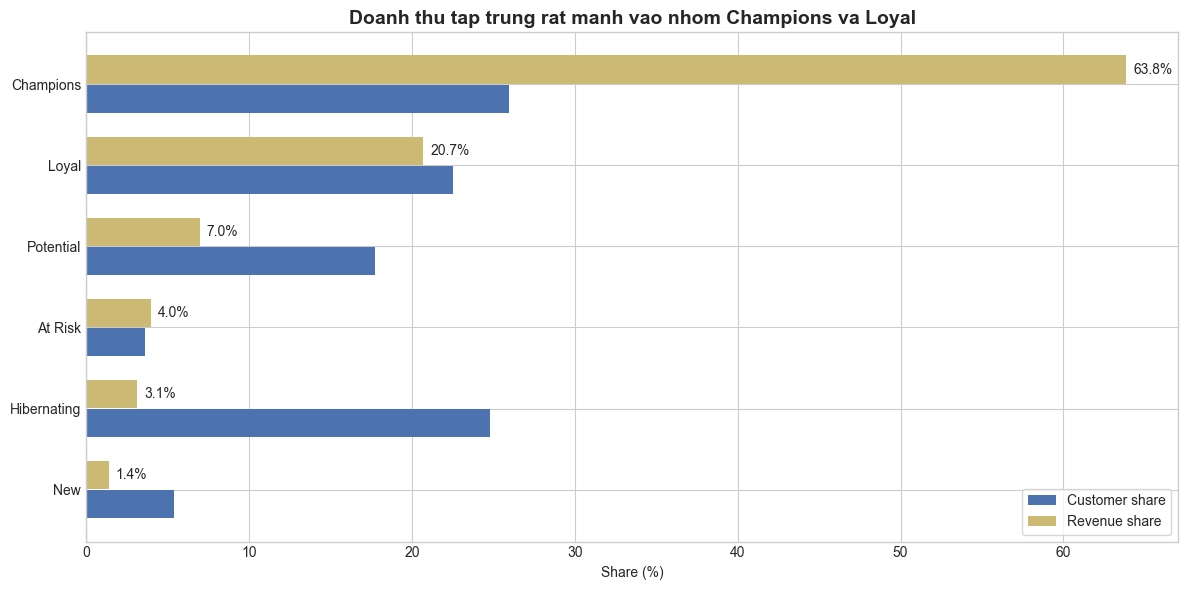

In [12]:
display(Markdown("## 4. Gia tri khach hang va uu tien giu chan"))

segment_plot = segment_summary.reset_index().rename(columns={"segment": "Segment"})
segment_plot = segment_plot.sort_values("revenue_share_pct", ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
y_pos = np.arange(len(segment_plot))
ax.barh(y_pos - 0.18, segment_plot["customer_share_pct"], height=0.35, color=BLUE, label="Customer share")
ax.barh(y_pos + 0.18, segment_plot["revenue_share_pct"], height=0.35, color=GOLD, label="Revenue share")
ax.set_yticks(y_pos)
ax.set_yticklabels(segment_plot["Segment"])
ax.set_xlabel("Share (%)")
ax.set_title("Doanh thu tap trung rat manh vao nhom Champions va Loyal", fontsize=14, fontweight="bold")
ax.legend(frameon=True)

for i, value in enumerate(segment_plot["revenue_share_pct"]):
    ax.annotate(f"{value:.1f}%", (value, y_pos[i] + 0.18), xytext=(5, 0), textcoords="offset points", va="center")

plt.tight_layout()
plt.show()

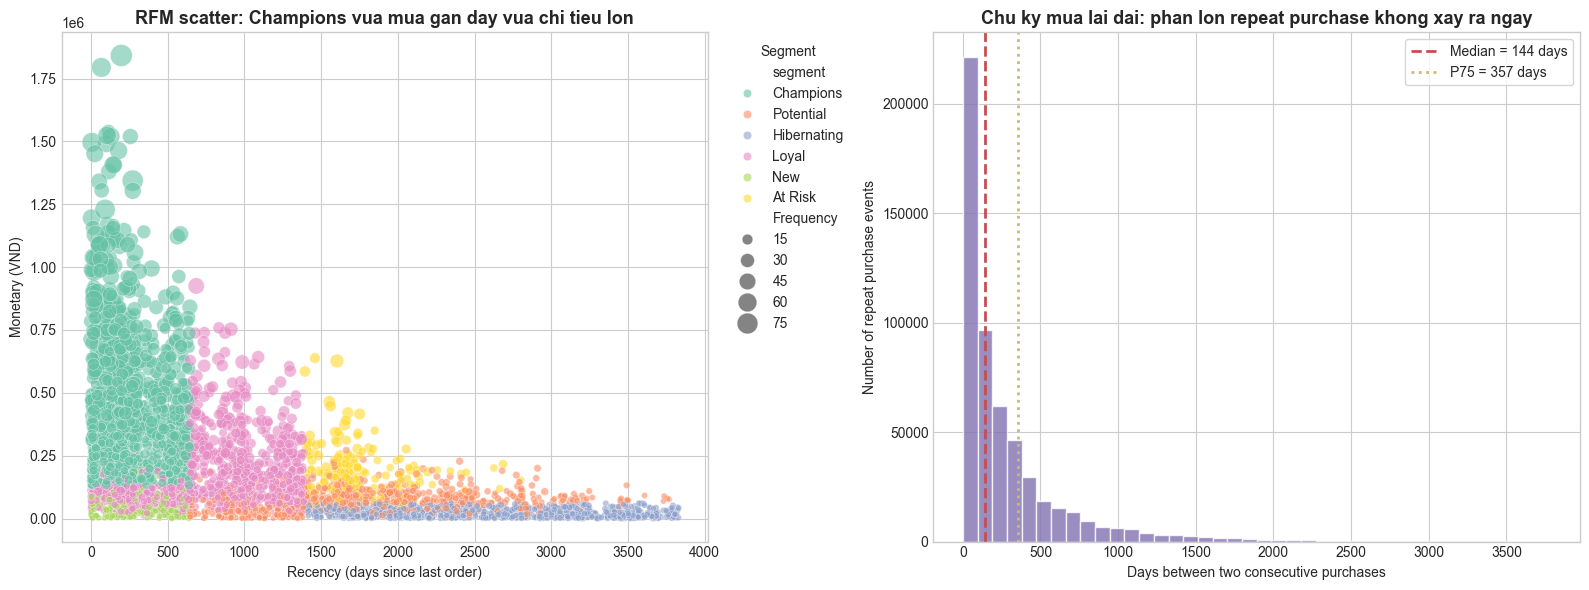

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=rfm_sample,
    x="Recency",
    y="Monetary",
    hue="segment",
    size="Frequency",
    sizes=(20, 250),
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title("RFM scatter: Champions vua mua gan day vua chi tieu lon", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Recency (days since last order)")
axes[0].set_ylabel("Monetary (VND)")
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Segment")

axes[1].hist(gap_series, bins=40, color=PURPLE, alpha=0.8, edgecolor="white")
axes[1].axvline(summary_metrics["median_gap_days"], color=RED, linestyle="--", linewidth=2, label=f"Median = {summary_metrics['median_gap_days']:.0f} days")
axes[1].axvline(summary_metrics["gap_q75"], color=GOLD, linestyle=":", linewidth=2, label=f"P75 = {summary_metrics['gap_q75']:.0f} days")
axes[1].set_title("Chu ky mua lai dai: phan lon repeat purchase khong xay ra ngay", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Days between two consecutive purchases")
axes[1].set_ylabel("Number of repeat purchase events")
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

### Phan tich 4 - Customer concentration va reactivation

**Descriptive.** `Champions` chiem **{summary_metrics['champions_customer_share']:.1f}%** customer base nhung tao ra **{summary_metrics['champions_revenue_share']:.1f}%** doanh thu. Trong khi do `Hibernating` chiem **{summary_metrics['hibernating_customer_share']:.1f}%** khach hang nhung chi dong gop **{summary_metrics['hibernating_revenue_share']:.1f}%** doanh thu.

**Diagnostic.** Co hai su that cung ton tai: doanh thu dang rat tap trung vao nhom khach hang tot nhat, va chu ky mua lai cua phan lon khach hang khong ngan. Median inter-order gap dat **{summary_metrics['median_gap_days']:.0f} ngay**, P75 len toi **{summary_metrics['gap_q75']:.0f} ngay**. Dieu nay cho thay bai toan khong chi la retention theo thang, ma la reactivation theo chu ky.

**Predictive.** Neu de nhom Champions roi vao At Risk, tac dong doanh thu se rat lon. Nguoc lai, chi can kich hoat lai mot phan nho Loyal / At Risk dung thoi diem da co the dem lai uplift tot hon so voi viec tiep tuc mua traffic dai tra.

**Prescriptive.** Nen xay CRM flow theo chu ky 90 / 180 / 360 ngay, tach uu dai cho `Champions` va `At Risk`, va dung trigger tu size / category da mua truoc do de nhac mua lai dung ngu canh.

## Tong hop de xuat hanh dong

1. **Dung mua traffic neu khong sua conversion.** KPI cua marketing can doi tu sessions sang `qualified traffic` va `orders per 1,000 visitors`.
2. **Reset promotion strategy.** Moi campaign can co guardrail ve gross margin theo category; tranh discount dong loat cho Streetwear va Casual.
3. **Xu ly returns o cap SKU.** Lap watchlist cho SKU / size co `wrong_size` va `defective` cao, uu tien sua PDP, size chart va QC.
4. **Tap trung bao ve Champions, kich hoat lai At Risk.** Day la don bay doanh thu nhanh hon va re hon so voi tiep tuc mo rong acquisition chat luong thap.

In [16]:
evidence_table = pd.DataFrame([
    {
        "Finding": "Traffic vs conversion",
        "Evidence": f"Sessions +{summary_metrics['sessions_growth_16_22']:.1f}% vs 2016, nhưng orders -{abs(summary_metrics['orders_change_16_22']):.1f}%"
    },
    {
        "Finding": "Promotion profitability",
        "Evidence": f"Promo chiếm {summary_metrics['promo_sales_share']:.1f}% net sales nhưng gross margin = {summary_metrics['promo_margin']:.1f}%"
    },
    {
        "Finding": "Top return driver",
        "Evidence": f"wrong_size chiếm {summary_metrics['wrong_size_refund_share']:.1f}% tổng refund"
    },
    {
        "Finding": "Customer concentration",
        "Evidence": f"Champions tạo {summary_metrics['champions_revenue_share']:.1f}% doanh thu từ {summary_metrics['champions_customer_share']:.1f}% khách hàng"
    },
    {
        "Finding": "Repurchase cadence",
        "Evidence": f"Median inter-order gap = {summary_metrics['median_gap_days']:.0f} ngày; P75 = {summary_metrics['gap_q75']:.0f} ngày"
    }
])

display(Markdown("### Bang chung cu then chot"))
display(evidence_table)

### Bang chung cu then chot

,Finding,Evidence
0,Traffic vs conversion,"Sessions +31.7% vs 2016, nhưng orders -56.2%"
1,Promotion profitability,Promo chiếm 29.9% net sales nhưng gross margin...
2,Top return driver,wrong_size chiếm 34.6% tổng refund
3,Customer concentration,Champions tạo 63.8% doanh thu từ 26.0% khách hàng
4,Repurchase cadence,Median inter-order gap = 144 ngày; P75 = 357 ngày
